In [55]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #img = img.astype(np.float32) / 255.0
    return img


def plot_images_grid(images, titles, cols=4, figsize=(12,6), heatmap=False):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='viridis' if heatmap else 'gray')
        plt.title(title)
        plt.axis("off")
        if heatmap:
            plt.colorbar()
    plt.tight_layout()
    plt.show()

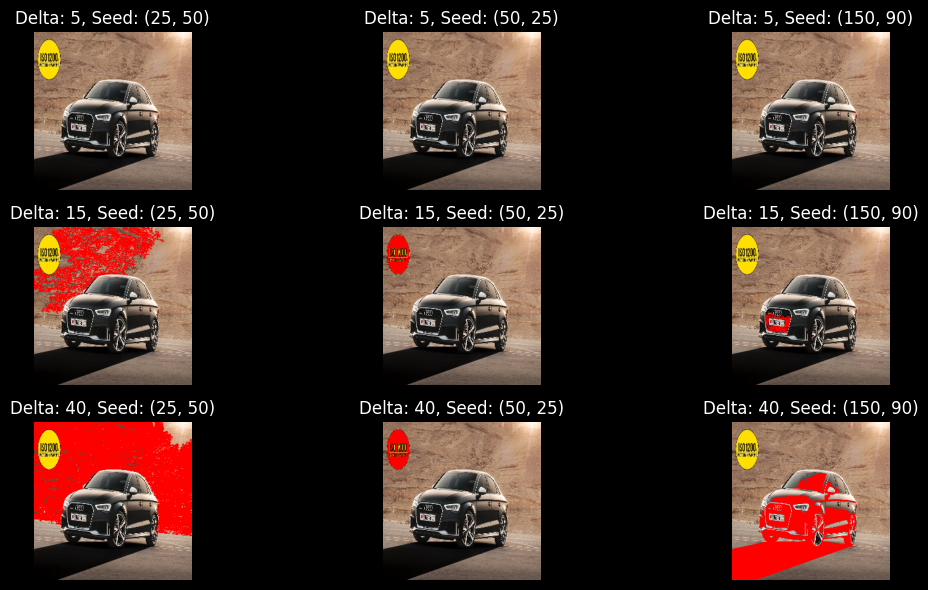

In [56]:
#1
from collections import deque
img = LoadImage('dark_object_light_background.jpg')

def region_growing_algorithm(img, seed, delta):
    h,w = img.shape
    seed_y, seed_x = seed
    seed_intensity = int(img[seed_y, seed_x])

    visited = np.zeros((h,w), dtype=bool)
    mask = np.zeros((h,w), dtype=np.uint8)

    queue = deque([(seed_y, seed_x)])
    queue.append((seed_y, seed_x))
    visited[seed_y, seed_x] = True

    while queue:
        y,x = queue.popleft()
        mask[y,x] = 255

        for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
            ny, nx = y + dy, x + dx

            if 0 <= ny < h and 0 <= nx < w:
                if not visited[ny,nx]:
                    visited[ny,nx] = True
                    if abs(int(img[ny,nx]) - int(seed_intensity)) <= delta:
                        queue.append((ny,nx))

    return mask

thresholds = [5, 15, 40]
result_img = []
names = []
seed_points = [(25,50), (50,25), (150, 90)]

overlay = cv2.imread('dark_object_light_background.jpg')
overlay = cv2.resize(overlay, (256,256))
overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

for t in thresholds:
    for s in seed_points:
        overlay_copy = overlay.copy()
        overlay_copy[(region_growing_algorithm(img, s, t) == 255)] = (255,0,0)
        names.append(f"Delta: {t}, Seed: {s}")
        result_img.append(overlay_copy)

plot_images_grid(result_img, names, cols=3, figsize=(12,6))



not sure if this is the best example picture
- Seed point: (25,50) - background mountain
- Seed point: (50,25) - yellow sign
- Seed point: (150,100) - car (kinda)